In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

Creating the directory structure to save Graphs and Output for Each Evaluator

In [2]:
output_data_path = os.path.join("output", "combined")
os.makedirs(output_data_path, exist_ok=True)

Reading the Evaluation data by Pathologist

In [3]:
evaluator_ids = ['evaluator1', 'evaluator2', 'evaluator3', 'evaluator4', 'evaluator5']
correct_answers_eval_data = {}
for evaluator_id in evaluator_ids:
    correct_answer_eval_data_path = f"output/{evaluator_id}/pathopen_image_augmentation_correct_answer_eval_data.pkl"
    eval_data = pd.read_pickle(correct_answer_eval_data_path)
    correct_answers_eval_data[evaluator_id] = eval_data

#### Combining all the dataframes into one combined dataframe for each Question Type and Evaluation Benchmark of Correct Answers

Open-Ended Clinical Relevance

In [4]:
correct_answers_open_ended_clin_relv = pd.DataFrame([correct_answers_eval_data['evaluator1'].loc['Clinical Relevance'].rename('Evaluator1'),
                                                      correct_answers_eval_data['evaluator2'].loc['Clinical Relevance'].rename('Evaluator2'),
                                                      correct_answers_eval_data['evaluator3'].loc['Clinical Relevance'].rename('Evaluator3'),
                                                      correct_answers_eval_data['evaluator4'].loc['Clinical Relevance'].rename('Evaluator4'),
                                                      correct_answers_eval_data['evaluator5'].loc['Clinical Relevance'].rename('Evaluator5')])

correct_answers_open_ended_clin_relv['Level 2'] = round((correct_answers_open_ended_clin_relv['Level 2']/correct_answers_open_ended_clin_relv['Total'])*100, 2)
correct_answers_open_ended_clin_relv['Level 1'] = round((correct_answers_open_ended_clin_relv['Level 1']/correct_answers_open_ended_clin_relv['Total'])*100, 2)
correct_answers_open_ended_clin_relv['Level 0'] = round((correct_answers_open_ended_clin_relv['Level 0']/correct_answers_open_ended_clin_relv['Total'])*100, 2)
correct_answers_open_ended_clin_relv['Level -1'] = round((correct_answers_open_ended_clin_relv['Level -1']/correct_answers_open_ended_clin_relv['Total'])*100, 2)
correct_answers_open_ended_clin_relv_total = correct_answers_open_ended_clin_relv['Total']
correct_answers_open_ended_clin_relv = correct_answers_open_ended_clin_relv.drop(columns=['Total']).rename(columns={'Level 2': '2',
                                                                                                                    'Level 1': '1',
                                                                                                                    'Level 0': '0',
                                                                                                                    'Level -1': '-1'})

correct_answers_open_ended_clin_relv

,2,1,0,-1
Evaluator1,93.94,4.55,1.52,0.00
Evaluator2,92.54,5.97,1.49,0.00
Evaluator3,95.52,4.48,0.00,0.00
Evaluator4,86.57,13.43,0.00,0.00
Evaluator5,74.32,6.76,6.76,12.16


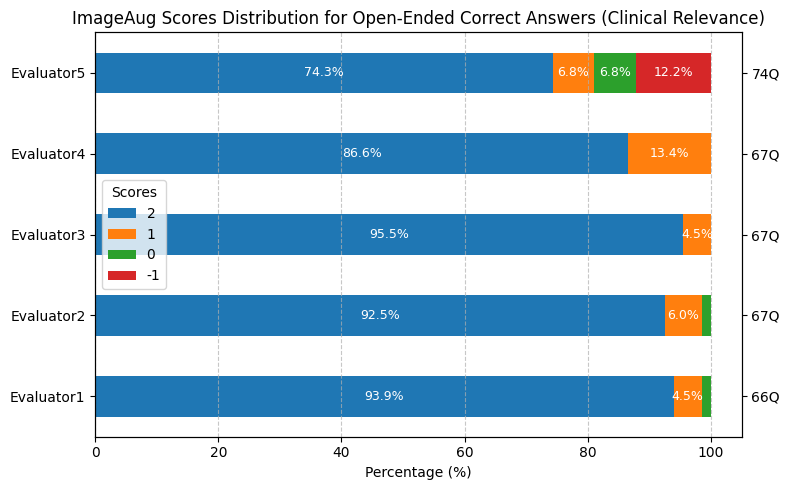

In [5]:
ax = correct_answers_open_ended_clin_relv.plot(kind='barh', stacked=True, figsize=(8, 5))
for container in ax.containers:
    labels = [f'{v.get_width():.1f}%' if v.get_width() > 4 else '' for v in container]
    ax.bar_label(container, label_type='center', fontsize=9, color='white', labels=labels)
ax2 = ax.twinx()
ax2.set_ylim(ax.get_ylim())
ax2.set_yticks(ax.get_yticks())
ax2.set_yticklabels([f"{val}Q" for val in correct_answers_open_ended_clin_relv_total], fontsize=10)
ax.set_title('ImageAug Scores Distribution for Open-Ended Correct Answers (Clinical Relevance)')
ax.set_xlabel('Percentage (%)')
ax.grid(axis='x', linestyle='--', alpha=0.7)
ax.legend(title='Scores', loc='best')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{output_data_path}/imageaug_open_ended_correct_answers_clin_relv.png')
plt.show()

Open-Ended Visual Grounding

In [6]:
correct_answers_open_ended_vis_grounding = pd.DataFrame([correct_answers_eval_data['evaluator1'].loc['Visual Grounding'].rename('Evaluator1'),
                                                      correct_answers_eval_data['evaluator2'].loc['Visual Grounding'].rename('Evaluator2'),
                                                      correct_answers_eval_data['evaluator3'].loc['Visual Grounding'].rename('Evaluator3'),
                                                      correct_answers_eval_data['evaluator4'].loc['Visual Grounding'].rename('Evaluator4'),
                                                      correct_answers_eval_data['evaluator5'].loc['Visual Grounding'].rename('Evaluator5')])

correct_answers_open_ended_vis_grounding['Level 2'] = round((correct_answers_open_ended_vis_grounding['Level 2']/correct_answers_open_ended_vis_grounding['Total'])*100, 2)
correct_answers_open_ended_vis_grounding['Level 1'] = round((correct_answers_open_ended_vis_grounding['Level 1']/correct_answers_open_ended_vis_grounding['Total'])*100, 2)
correct_answers_open_ended_vis_grounding['Level 0'] = round((correct_answers_open_ended_vis_grounding['Level 0']/correct_answers_open_ended_vis_grounding['Total'])*100, 2)
correct_answers_open_ended_vis_grounding['Level -1'] = round((correct_answers_open_ended_vis_grounding['Level -1']/correct_answers_open_ended_vis_grounding['Total'])*100, 2)
correct_answers_open_ended_vis_grounding_total = correct_answers_open_ended_vis_grounding['Total']
correct_answers_open_ended_vis_grounding = correct_answers_open_ended_vis_grounding.drop(columns=['Total']).rename(columns={'Level 2': '2',
                                                                                                                    'Level 1': '1',
                                                                                                                    'Level 0': '0',
                                                                                                                    'Level -1': '-1'})

correct_answers_open_ended_vis_grounding

,2,1,0,-1
Evaluator1,96.97,1.52,1.52,0.00
Evaluator2,86.57,11.94,1.49,0.00
Evaluator3,94.03,5.97,0.00,0.00
Evaluator4,70.15,23.88,5.97,0.00
Evaluator5,74.32,6.76,9.46,9.46


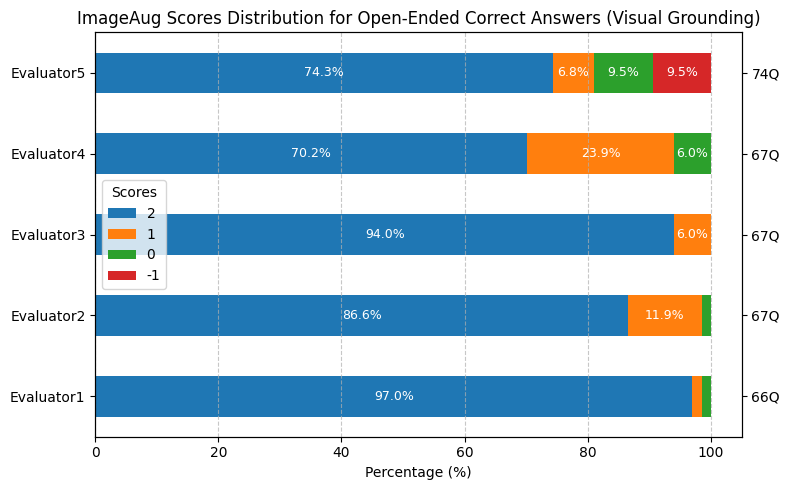

In [7]:
ax = correct_answers_open_ended_vis_grounding.plot(kind='barh', stacked=True, figsize=(8, 5))
for container in ax.containers:
    labels = [f'{v.get_width():.1f}%' if v.get_width() > 4 else '' for v in container]
    ax.bar_label(container, label_type='center', fontsize=9, color='white', labels=labels)
ax2 = ax.twinx()
ax2.set_ylim(ax.get_ylim())
ax2.set_yticks(ax.get_yticks())
ax2.set_yticklabels([f"{val}Q" for val in correct_answers_open_ended_vis_grounding_total], fontsize=10)
ax.set_title('ImageAug Scores Distribution for Open-Ended Correct Answers (Visual Grounding)')
ax.set_xlabel('Percentage (%)')
ax.grid(axis='x', linestyle='--', alpha=0.7)
ax.legend(title='Scores', loc='best')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{output_data_path}/imageaug_open_ended_correct_answers_vis_grounding.png')
plt.show()